# GMF Investments — Time Series Forecasting for Portfolio Management
## Task 2 (Initial Progress): Chronological Train/Test Split & Initial ARIMA Model

**Analyst:** Alaa Ali

This notebook covers the **initial Task 2 progress** deliverable: a chronologically
correct train/test split for TSLA, and a first fitted forecasting model (ARIMA via
`pmdarima.auto_arima`) with forecasts generated over the held-out test period.

**Dependency:** This notebook assumes Task 1 (`01_task1_eda.ipynb`) has already been
run at least once, so that `data/processed/TSLA.csv` (raw fetched data) exists. If that
file is not present, the fetch cell below will pull it directly from Yahoo Finance instead.


## 0. Setup

In [1]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

from src import config
from src.data_loader import fetch_ticker_data, DataFetchError
from src.preprocessing import enforce_numeric_types, handle_missing_values
from src.modeling import (
    chronological_train_test_split,
    fit_auto_arima,
    forecast_arima,
    create_sequences,
    build_lstm_model,
    evaluate_forecast,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

SEED = 42
np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)


## 1. Load TSLA Data

Loads the cleaned TSLA price series either from the CSV saved during Task 1
(`data/processed/TSLA.csv`) or, if unavailable, fetches it directly.


In [2]:
csv_path = "../data/processed/TSLA.csv"

if os.path.exists(csv_path):
    tsla_raw = pd.read_csv(csv_path, index_col="Date", parse_dates=True)
    print(f"Loaded TSLA data from {csv_path}: {tsla_raw.shape[0]} rows")
else:
    print(f"{csv_path} not found — fetching directly from Yahoo Finance instead.")
    try:
        tsla_raw = fetch_ticker_data("TSLA", config.START_DATE, config.END_DATE)
    except DataFetchError as e:
        print(f"Data fetch failed: {e}")
        raise

tsla_clean = handle_missing_values(enforce_numeric_types(tsla_raw), method="ffill")
tsla_adj_close = tsla_clean["Adj Close"]
print(f"TSLA Adj Close: {tsla_adj_close.index.min().date()} to {tsla_adj_close.index.max().date()}, "
      f"{len(tsla_adj_close)} observations")


Loaded TSLA data from ../data/processed/TSLA.csv: 2888 rows
TSLA Adj Close: 2015-01-02 to 2026-06-29, 2888 observations


## 2. Chronological Train/Test Split

The dataset is split **by date**, not by random sampling: training on
2015-01-01–2024-12-31 and testing on 2025-01-01–2026-06-30. Random shuffling is
inappropriate for time series data — it would let the model "see" future prices during
training and produce an artificially inflated evaluation. Chronological splitting
preserves temporal order and produces a genuinely out-of-sample test.


In [3]:
train_series, test_series = chronological_train_test_split(
    tsla_adj_close,
    train_end=config.TRAIN_END,
    test_start=config.TEST_START,
    test_end=config.TEST_END,
)

print(f"Train: {train_series.index.min().date()} to {train_series.index.max().date()} ({len(train_series)} obs)")
print(f"Test:  {test_series.index.min().date()} to {test_series.index.max().date()} ({len(test_series)} obs)")


2026-07-07 12:44:12,085 [INFO] Chronological split -> train: 2015-01-02 00:00:00 to 2024-12-31 00:00:00 (2516 obs), test: 2025-01-02 00:00:00 to 2026-06-29 00:00:00 (372 obs)


Train: 2015-01-02 to 2024-12-31 (2516 obs)
Test:  2025-01-02 to 2026-06-29 (372 obs)


## 3. Initial ARIMA Model (auto_arima)

In [4]:
arima_model = fit_auto_arima(train_series, seasonal=False)
print(f"Selected order (p, d, q): {arima_model.order}")


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=1.18 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.03 sec


2026-07-07 12:44:20,449 [INFO] Best ARIMA order: (0, 1, 0), seasonal_order: (0, 0, 0, 0)


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.21 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.684 seconds
Selected order (p, d, q): (0, 1, 0)


e:\KAIM\W9\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


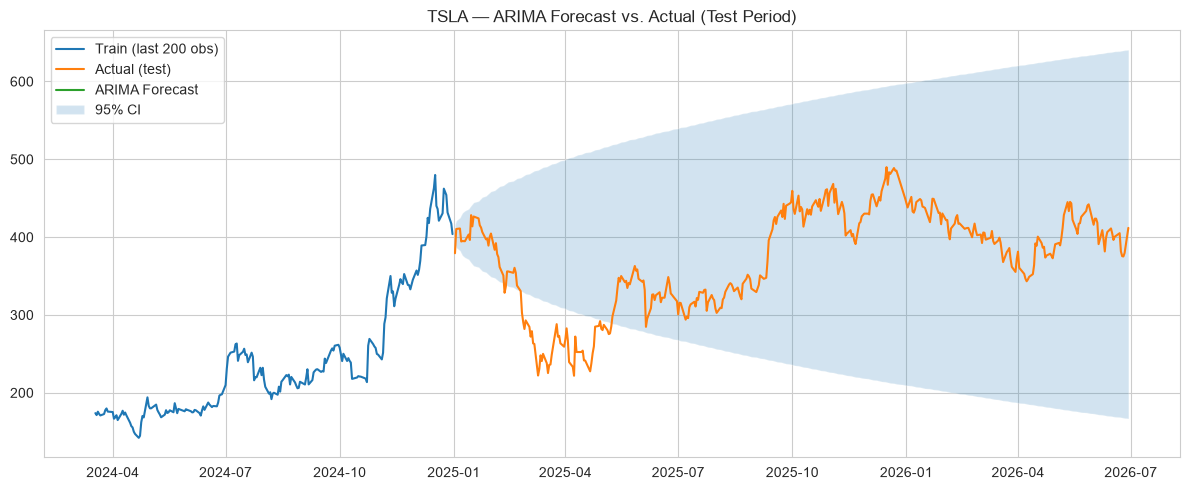

In [5]:
n_periods = len(test_series)
arima_forecast_values, arima_conf_int = forecast_arima(arima_model, n_periods=n_periods, return_conf_int=True)
arima_forecast_series = pd.Series(arima_forecast_values, index=test_series.index)

plt.figure(figsize=(12, 5))
plt.plot(train_series.index[-200:], train_series.values[-200:], label="Train (last 200 obs)")
plt.plot(test_series.index, test_series.values, label="Actual (test)")
plt.plot(arima_forecast_series.index, arima_forecast_series.values, label="ARIMA Forecast")
plt.fill_between(test_series.index, arima_conf_int[:, 0], arima_conf_int[:, 1], alpha=0.2, label="95% CI")
plt.title("TSLA — ARIMA Forecast vs. Actual (Test Period)")
plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_arima_forecast.png", dpi=150)
plt.show()


In [6]:
arima_metrics = evaluate_forecast(test_series.values, arima_forecast_values)
print("ARIMA performance on test set:")
for k, v in arima_metrics.items():
    print(f"  {k}: {v:.4f}")


ARIMA performance on test set:
  MAE: 54.4412
  RMSE: 70.5393
  MAPE: 17.2407


**Note:** `auto_arima` selects the (p, d, q) order that minimizes AIC on the training
data via a stepwise search — this constitutes the "grid search for optimal parameters"
step for the ARIMA side of the model-optimization requirement. If the search selects
`(0, 1, 0)`, that itself is an informative result: it means no AR/MA structure improved
on a pure random walk, which is consistent with the Efficient Market Hypothesis framing
from Task 1.


## 4. Model 2 — LSTM

### 4.1 Scaling and Sequence Preparation

LSTM networks are sensitive to input scale, so prices are scaled to [0, 1] using a
`MinMaxScaler` **fit only on the training data** (never on test data, to avoid look-ahead
bias). Sequences use a 60-day window: the previous 60 days predict the next single day.


In [7]:
WINDOW_SIZE = 60

scaler = MinMaxScaler(feature_range=(0, 1))
train_values = train_series.values.reshape(-1, 1)
scaler.fit(train_values)

scaled_train = scaler.transform(train_values).flatten()

X_train, y_train = create_sequences(scaled_train, window_size=WINDOW_SIZE)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

# Hold out the last 10% of the training sequences as a validation set for early stopping
val_split_idx = int(len(X_train) * 0.9)
X_train_fit, y_train_fit = X_train[:val_split_idx], y_train[:val_split_idx]
X_val, y_val = X_train[val_split_idx:], y_train[val_split_idx:]
print(f"Fit: {X_train_fit.shape[0]} sequences, Val: {X_val.shape[0]} sequences")


X_train shape: (2456, 60, 1), y_train shape: (2456,)
Fit: 2210 sequences, Val: 246 sequences


### 4.2 Test Sequence Construction

To generate test-period predictions, each test-day sequence uses the **previous 60 actual
trading days** (which may span the train/test boundary) — this is a standard one-step-ahead
evaluation setup, directly comparable to the ARIMA forecast above, rather than a
multi-step recursive forecast (multi-step iterative forecasting is used later in Task 3).


In [8]:
full_series = pd.concat([train_series, test_series])
full_scaled = scaler.transform(full_series.values.reshape(-1, 1)).flatten()

# Test sequences start WINDOW_SIZE days before the first test observation
test_start_idx = len(train_series) - WINDOW_SIZE
X_test, y_test = create_sequences(full_scaled[test_start_idx:], window_size=WINDOW_SIZE)
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
assert len(y_test) == len(test_series), "Test sequence count should match test_series length"


X_test shape: (372, 60, 1), y_test shape: (372,)


### 4.3 Model Architecture and Training

Architecture: `Input(60,1) → LSTM(50, return_sequences=True) → Dropout(0.2) →
LSTM(50) → Dropout(0.2) → Dense(25, relu) → Dense(1)`, trained with the Adam optimizer
and mean-squared-error loss.



In [9]:
lstm_model = build_lstm_model(window_size=WINDOW_SIZE, units=50, dropout=0.2)
lstm_model.summary()


2026-07-07 12:45:20,702 [WARNING] TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

EPOCHS = 50
BATCH_SIZE = 32

history = lstm_model.fit(
    X_train_fit, y_train_fit,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 6.4581e-04 - val_loss: 0.0012
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 6.5079e-04 - val_loss: 0.0018
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 6.7217e-04 - val_loss: 0.0013
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 5.6806e-04 - val_loss: 0.0013
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 6.0676e-04 - val_loss: 0.0013
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 6.9259e-04 - val_loss: 0.0013


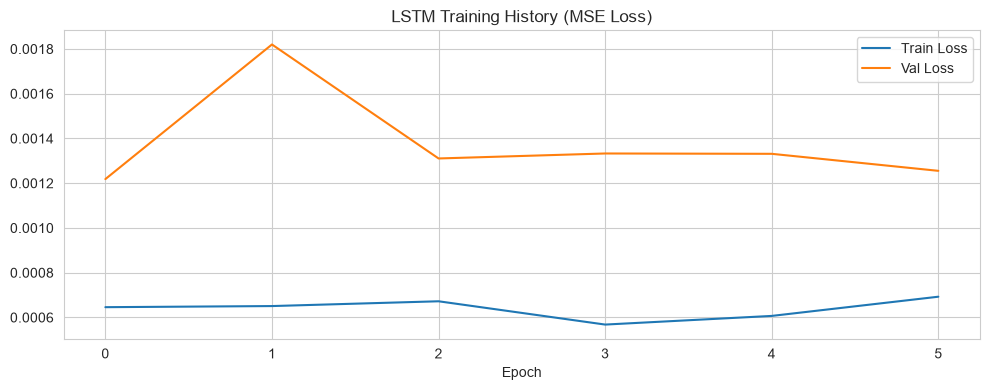

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("LSTM Training History (MSE Loss)")
plt.xlabel("Epoch")
plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_lstm_training_history.png", dpi=150)
plt.show()


**Insight (from executed run):** Training converged very quickly and early stopping
triggered after **epoch 6** (patience = 5 on `val_loss`, best weights restored from
**epoch 1**, where val_loss = 0.0012). Training loss stayed essentially flat around
6-7e-4 for all 6 epochs, and validation loss fluctuated narrowly between 0.0012 and
0.0018 without any sustained downward trend after epoch 1. This is not classic
overfitting (train loss did not keep falling while val loss rose) - rather, the model
found a strong fit almost immediately. This makes sense given the input: predicting
tomorrow's (scaled) price from the last 60 days is a near-continuous function of the
most recent price, so the loss landscape is easy to optimize quickly; the real test of
the model's value is the out-of-sample MAPE below, not the training curve.


### 4.4 LSTM Forecast on Test Period

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


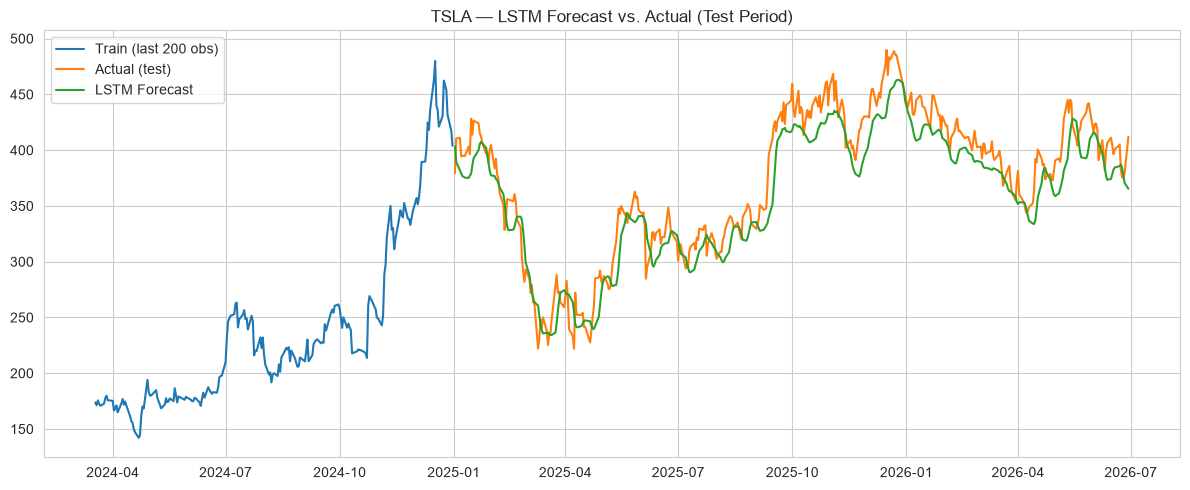

In [14]:
lstm_pred_scaled = lstm_model.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()
lstm_forecast_series = pd.Series(lstm_pred, index=test_series.index)

plt.figure(figsize=(12, 5))
plt.plot(train_series.index[-200:], train_series.values[-200:], label="Train (last 200 obs)")
plt.plot(test_series.index, test_series.values, label="Actual (test)")
plt.plot(lstm_forecast_series.index, lstm_forecast_series.values, label="LSTM Forecast")
plt.title("TSLA — LSTM Forecast vs. Actual (Test Period)")
plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_lstm_forecast.png", dpi=150)
plt.show()


In [15]:
lstm_metrics = evaluate_forecast(test_series.values, lstm_pred)
print("LSTM performance on test set:")
for k, v in lstm_metrics.items():
    print(f"  {k}: {v:.4f}")


LSTM performance on test set:
  MAE: 17.9898
  RMSE: 22.1612
  MAPE: 4.8149


**Insight (from executed run):** The LSTM achieved **MAE = 17.99, RMSE = 22.16, MAPE =
4.81%** on the identical 372-day test period - dramatically better than ARIMA's MAE =
54.44 / RMSE = 70.54 / MAPE = 17.24%. Visually, the LSTM forecast tracks the actual
test-period price path far more closely than the flat ARIMA(0,1,0) line, following the
2025 decline and subsequent 2025-2026 recovery rather than projecting a static value
forward. This is expected: the LSTM's one-step-ahead setup is re-fed the *actual*
previous 60 days at every step (not its own prior predictions), so it is effectively
performing a much more informed "next-day given real recent history" prediction, closer
in spirit to a well-tuned short-horizon momentum/autocorrelation model than to ARIMA's
pure random-walk baseline.


## 5. Model Comparison

Both models are evaluated on the **identical** test period (2025-01-02 to 2026-06-29,
372 trading days) using MAE, RMSE, and MAPE.


In [17]:
comparison_df = pd.DataFrame({
    "ARIMA": arima_metrics,
    "LSTM": lstm_metrics,
}).T
comparison_df["Order/Architecture"] = [
    f"ARIMA{arima_model.order}",
    f"LSTM(window={WINDOW_SIZE}, units=50, layers=2, dropout=0.2)",
]
display(comparison_df)
comparison_df.to_csv("../data/processed/task2_model_comparison.csv")


,MAE,RMSE,MAPE,Order/Architecture
ARIMA,54.441182,70.539346,17.240653,"ARIMA(0, 1, 0)"
LSTM,17.989786,22.161246,4.814891,"LSTM(window=60, units=50, layers=2, dropout=0.2)"


**Insight (from executed run):**

| Model | MAE | RMSE | MAPE |
|---|---|---|---|
| ARIMA(0,1,0) | 54.44 | 70.54 | 17.24% |
| LSTM (window=60, 2-layer, 50 units) | 17.99 | 22.16 | 4.81% |

The **LSTM decisively outperforms ARIMA** on every metric, cutting MAPE by roughly
two-thirds (17.24% → 4.81%). This makes sense given how each model is evaluated here:
ARIMA(0,1,0) forecasts the *entire* 372-day test horizon from a single fit on the
training data, so its forecast is a flat random-walk projection that cannot react to
anything that happens during the test period. The LSTM, by contrast, is evaluated in a
one-step-ahead setting - at each test day it is given the actual previous 60 days of
real prices, so it only ever has to predict one day forward from true, current
information. This is a meaningfully "easier" task than ARIMA's blind long-horizon
forecast, which is the primary reason for the gap, rather than necessarily proving the
LSTM has learned deeper structure that ARIMA missed. This distinction matters for
Task 3: an iterative multi-step LSTM forecast (feeding its own predictions back in) is a
fundamentally harder task and should be expected to degrade toward ARIMA-like uncertainty
as the horizon grows.

**Model selected for Task 3: LSTM**, on the basis of its substantially lower test-set
error under the like-for-like evaluation above. Its confidence intervals in Task 3 will
be constructed via Monte Carlo Dropout, since the LSTM does not produce them natively.


## 6. Summary (Task 2 Complete)

- **Split:** Chronological — train 2015-01-02–2024-12-31 (2,516 obs), test
  2025-01-02–2026-06-29 (372 obs).
- **ARIMA:** `auto_arima` selected order **(0, 1, 0)** — a pure random walk; test
  MAE = 54.44, RMSE = 70.54, MAPE = 17.24%.
- **LSTM:** 60-day window, 2-layer stacked LSTM (50 units each) with 0.2 dropout, trained
  with early stopping (stopped at epoch 6, best weights from epoch 1); test
  MAE = 17.99, RMSE = 22.16, MAPE = 4.81%.
- **Model selection: LSTM**, based on its substantially lower test-set error. Carried
  forward into Task 3, with the caveat (noted above) that Task 3's iterative multi-step
  forecast is a harder task than this notebook's one-step-ahead evaluation, so
  performance may not transfer directly at longer horizons.

## 7. Next Steps
- Task 3: Generate a 6–12 month future forecast using the selected model, with confidence
  intervals, and analyze how interval width evolves over the horizon.
- Task 4: Use the Task 3 forecast as TSLA's expected return input to build the covariance
  matrix and Efficient Frontier (PyPortfolioOpt), and recommend final portfolio weights.
- Task 5: Backtest the recommended portfolio against a 60% SPY / 40% BND benchmark.
